In [1]:
import numpy as np

deg = {'SOFT': {'base': 90.0, 'd': 0.0844},
       'MEDIUM': {'base': 90.6, 'd': 0.0369},
       'HARD': {'base': 91.2, 'd': 0.0521}}
FUEL = -0.10
PIT_LOSS = 26.4          # green pit cost (measured)
PIT_SC   = 12.0          # pit cost under safety car (cited, Aguad)
N_LAPS   = 57
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

P_SC   = 0.0135          # your 2025 measurement: 54%/race -> ~1.35%/lap
SC_DUR = 4               # (legacy) unused; the chain now has 2 states
Q_END  = 0.25            # SC ends per lap (memoryless); E[dur]=1/q=4
SC_LAP_TIME = 140.0      # everyone crawls; same for all, so it doesn't distort choices

def lap_time(compound, tyre_age, lap_number):
    p = deg[compound]
    return p['base'] + p['d'] * tyre_age + FUEL * lap_number

In [2]:
def flag_transition(f):
    """Returns list of (next_flag, probability). The Markov chain."""
    if f == 0:                       # green now
        return [(0, 1 - P_SC), (1, P_SC)]
    else:                            # under SC: ends w.p. Q_END, else continues
        return [(1, 1 - Q_END), (0, Q_END)]

# visualize it as a matrix
states = list(range(2))     # 0=green, 1=under safety car
T = np.zeros((len(states), len(states)))
for f in states:
    for nf, p in flag_transition(f):
        T[f, nf] = p
print("Flag transition matrix (rows=now, cols=next):")
print(np.round(T, 4))

Flag transition matrix (rows=now, cols=next):
[[0.9865 0.0135]
 [0.25   0.75  ]]


In [3]:
B_MAX   = 4        # battery levels 0..4 (~1 MJ each, FIA 2026: 4 MJ usable)
DELTA   = 0.4      # deploy = -0.4s this lap; harvest = +0.4s (stylized; sweep later)
SC_RECHARGE = 1    # each SC lap refills 1 level for free (the 2026 coupling)
ENERGY_ACTIONS = ['deploy', 'hold', 'harvest']

In [4]:
import numpy as np

def solve_sdp(battery=True):
    NC, NA, NM, NF, NB = 3, N_LAPS + 1, 2, 2, B_MAX + 1
    INF = float('inf')
    V   = np.full((N_LAPS + 2, NC, NA, NM, NF, NB), INF)
    PPOL = np.full((N_LAPS + 1, NC, NA, NM, NF, NB), -1, dtype=int)  # -1 stay, 0/1/2 pit-to
    EPOL = np.full((N_LAPS + 1, NC, NA, NM, NF, NB), 1,  dtype=int)  # 0 deploy,1 hold,2 harvest
    V[N_LAPS + 1, :, :, 1, :, :] = 0.0                # legal finishes

    energy_opts = [0, 1, 2] if battery else [1]        # OFF: hold only

    for n in range(N_LAPS, 0, -1):
        for ci in range(NC):
            c = COMPOUNDS[ci]
            for a in range(NA):
                for m in range(NM):
                    for f in range(NF):
                        for b in range(NB):
                            best, bp, be = INF, -1, 1
                            if f == 0:  # ---- GREEN ----
                                for e in energy_opts:
                                    if e == 0 and b == 0: continue        # can't deploy empty
                                    if e == 2 and b == B_MAX: continue    # can't harvest full
                                    dt = (-DELTA if e == 0 else DELTA if e == 2 else 0.0)
                                    b2 = b - 1 if e == 0 else b + 1 if e == 2 else b
                                    # stay
                                    if a + 1 < NA:
                                        cost = lap_time(c, a + 1, n) + dt
                                        ev = sum(p * V[n+1, ci, a+1, m, nf, b2]
                                                 for nf, p in flag_transition(f))
                                        if cost + ev < best: best, bp, be = cost + ev, -1, e
                                    # pit to x
                                    for xi in range(NC):
                                        m2 = 1 if (xi != ci or m == 1) else 0
                                        cost = lap_time(COMPOUNDS[xi], 1, n) + PIT_LOSS + dt
                                        ev = sum(p * V[n+1, xi, 1, m2, nf, b2]
                                                 for nf, p in flag_transition(f))
                                        if cost + ev < best: best, bp, be = cost + ev, xi, e
                            else:       # ---- SAFETY CAR ----
                                b2 = min(B_MAX, b + SC_RECHARGE) if battery else b
                                # stay (no wear, free recharge)
                                cost = SC_LAP_TIME
                                ev = sum(p * V[n+1, ci, a, m, nf, b2]
                                         for nf, p in flag_transition(f))
                                if cost + ev < best: best, bp, be = cost + ev, -1, 1
                                # pit cheap
                                for xi in range(NC):
                                    m2 = 1 if (xi != ci or m == 1) else 0
                                    cost = SC_LAP_TIME + PIT_SC
                                    ev = sum(p * V[n+1, xi, 0, m2, nf, b2]
                                             for nf, p in flag_transition(f))
                                    if cost + ev < best: best, bp, be = cost + ev, xi, 1
                            V[n, ci, a, m, f, b] = best
                            PPOL[n, ci, a, m, f, b] = bp
                            EPOL[n, ci, a, m, f, b] = be
        if n % 10 == 0: print(f"  [battery={'ON' if battery else 'OFF'}] solved to lap {n}")
    return V, PPOL, EPOL

print("Solving battery OFF (pre-2026)...")
V_off, P_off, E_off = solve_sdp(battery=False)
print("Solving battery ON (2026)...")
V_on,  P_on,  E_on  = solve_sdp(battery=True)
print("\nExpected time, SOFT start, half battery:")
print("  OFF:", round(V_off[1, 0, 0, 0, 0, 2], 1))
print("  ON: ", round(V_on [1, 0, 0, 0, 0, 2], 1))

Solving battery OFF (pre-2026)...
  [battery=OFF] solved to lap 50
  [battery=OFF] solved to lap 40


  [battery=OFF] solved to lap 30


  [battery=OFF] solved to lap 20
  [battery=OFF] solved to lap 10


Solving battery ON (2026)...


  [battery=ON] solved to lap 50


  [battery=ON] solved to lap 40


  [battery=ON] solved to lap 30


  [battery=ON] solved to lap 20


  [battery=ON] solved to lap 10



Expected time, SOFT start, half battery:
  OFF: 5194.3
  ON:  5192.8


In [5]:
def simulate_b(PPOL, EPOL, flags, start_comp='SOFT', b0=2, battery=True):
    ci, a, m, b, total = COMPOUNDS.index(start_comp), 0, 0, b0, 0.0
    pits, deploys = [], []
    for n in range(1, N_LAPS + 1):
        f = flags[n - 1]
        pa, ea = PPOL[n, ci, a, m, f, b], EPOL[n, ci, a, m, f, b]
        if f == 0:
            dt = (-DELTA if ea == 0 else DELTA if ea == 2 else 0.0)
            if ea == 0: deploys.append(n)
            b = b - 1 if ea == 0 else min(B_MAX, b + 1) if ea == 2 else b
            if pa == -1:
                a += 1; total += lap_time(COMPOUNDS[ci], a, n) + dt
            else:
                pits.append((n, COMPOUNDS[pa], 'green'))
                if pa != ci or m == 1: m = 1
                ci, a = pa, 1
                total += lap_time(COMPOUNDS[ci], a, n) + PIT_LOSS + dt
        else:
            if battery: b = min(B_MAX, b + SC_RECHARGE)
            if pa == -1: total += SC_LAP_TIME
            else:
                pits.append((n, COMPOUNDS[pa], 'SC'))
                if pa != ci or m == 1: m = 1
                ci, a = pa, 0
                total += SC_LAP_TIME + PIT_SC
    return total, pits, deploys

In [6]:
all_green = [0] * N_LAPS
t_off, pits_off, _  = simulate_b(P_off, E_off, all_green, battery=False)
t_on,  pits_on,  dep = simulate_b(P_on,  E_on,  all_green, battery=True)
print(f"BATTERY OFF (pre-2026): pits {pits_off}, time {t_off:.1f}s")
print(f"BATTERY ON  (2026):     pits {pits_on},  time {t_on:.1f}s")
print(f"Deploy laps (ON): {dep}")

BATTERY OFF (pre-2026): pits [(24, 'MEDIUM', 'green')], time 5056.7s
BATTERY ON  (2026):     pits [(24, 'MEDIUM', 'green')],  time 5055.9s
Deploy laps (ON): [1, 2]


In [7]:
flags = [0]*19 + [1,1,1,1] + [0]*(N_LAPS - 23)
t1, p1, _  = simulate_b(P_off, E_off, flags, battery=False)
t2, p2, d2 = simulate_b(P_on,  E_on,  flags, battery=True)
print(f"OFF: pits {p1}, time {t1:.1f}s")
print(f"ON:  pits {p2}, time {t2:.1f}s, deploys {d2}")

OFF: pits [(20, 'MEDIUM', 'SC')], time 5243.7s
ON:  pits [(20, 'MEDIUM', 'SC')], time 5241.3s, deploys [1, 2, 24, 25, 26, 27]


In [8]:
for test_delta in [0.2, 0.4, 0.8, 1.2]:
    globals()['DELTA'] = test_delta
    _, P_t, E_t = solve_sdp(battery=True)
    _, pits_t, _ = simulate_b(P_t, E_t, [0]*N_LAPS, battery=True)
    print(f"delta={test_delta}: green-path pit -> {pits_t}")
DELTA = 0.4

  [battery=ON] solved to lap 50


  [battery=ON] solved to lap 40


  [battery=ON] solved to lap 30


  [battery=ON] solved to lap 20


  [battery=ON] solved to lap 10


...

  [battery=ON] solved to lap 40


  [battery=ON] solved to lap 30


  [battery=ON] solved to lap 20


  [battery=ON] solved to lap 10


delta=1.2: green-path pit -> [(24, 'MEDIUM', 'green')]


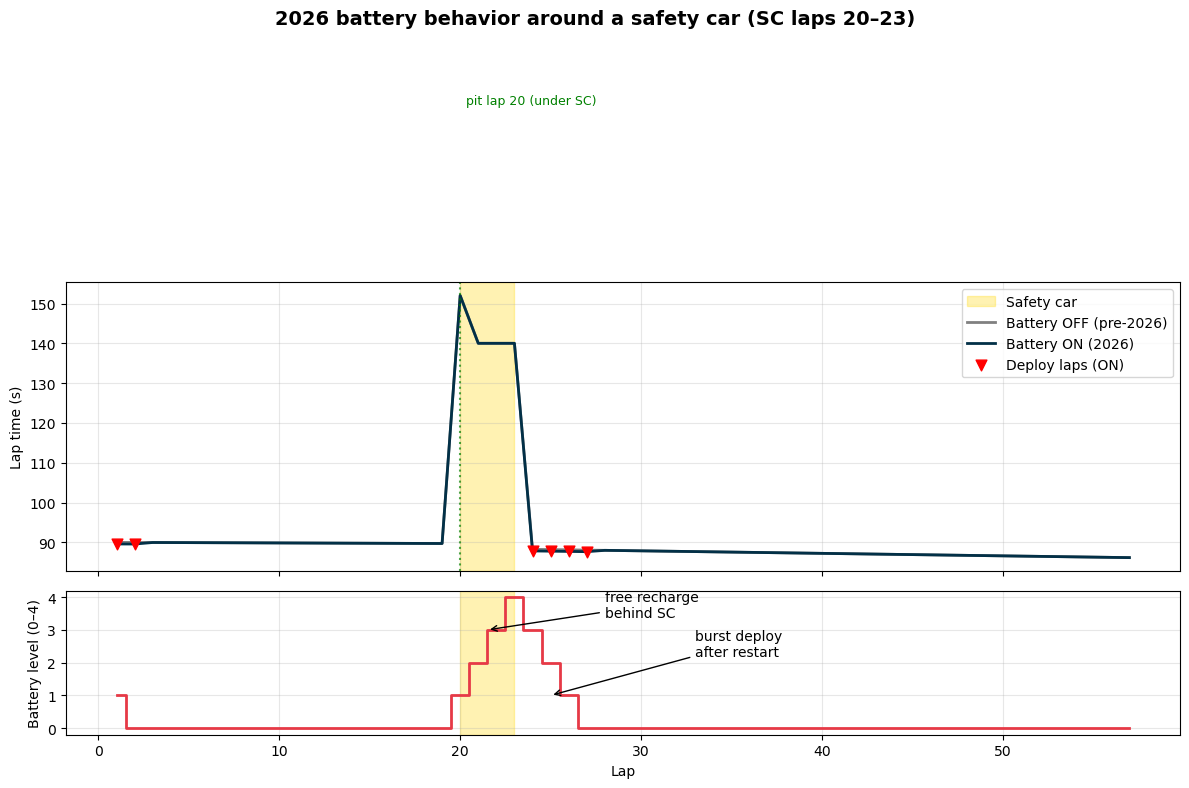

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def trace_race(PPOL, EPOL, flags, start_comp='SOFT', b0=2, battery=True):
    """Like simulate_b but records lap-by-lap history for plotting."""
    ci, a, m, b = COMPOUNDS.index(start_comp), 0, 0, b0
    hist = {'lap': [], 'time': [], 'batt': [], 'deploy': [], 'pit': []}
    for n in range(1, N_LAPS + 1):
        f = flags[n - 1]
        pa, ea = PPOL[n, ci, a, m, f, b], EPOL[n, ci, a, m, f, b]
        deployed, pitted = False, False
        if f == 0:
            dt = (-DELTA if ea == 0 else DELTA if ea == 2 else 0.0)
            deployed = (ea == 0)
            b = b - 1 if ea == 0 else min(B_MAX, b + 1) if ea == 2 else b
            if pa == -1:
                a += 1; lt = lap_time(COMPOUNDS[ci], a, n) + dt
            else:
                pitted = True
                if pa != ci or m == 1: m = 1
                ci, a = pa, 1
                lt = lap_time(COMPOUNDS[ci], a, n) + PIT_LOSS + dt
        else:
            if battery: b = min(B_MAX, b + SC_RECHARGE)
            if pa == -1: lt = SC_LAP_TIME
            else:
                pitted = True
                if pa != ci or m == 1: m = 1
                ci, a = pa, 0
                lt = SC_LAP_TIME + PIT_SC
        hist['lap'].append(n); hist['time'].append(lt)
        hist['batt'].append(b); hist['deploy'].append(deployed); hist['pit'].append(pitted)
    return hist

flags_sc = [0]*19 + [1,1,1,1] + [0]*(N_LAPS - 23)
h_on  = trace_race(P_on,  E_on,  flags_sc, battery=True)
h_off = trace_race(P_off, E_off, flags_sc, battery=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('2026 battery behavior around a safety car (SC laps 20–23)',
             fontsize=14, fontweight='bold')

# Panel 1: lap times
ax1.axvspan(20, 23, color='gold', alpha=0.3, label='Safety car')
ax1.plot(h_off['lap'], h_off['time'], color='gray', lw=2, label='Battery OFF (pre-2026)')
ax1.plot(h_on['lap'],  h_on['time'],  color='#023047', lw=2, label='Battery ON (2026)')
dep_laps = [l for l, d in zip(h_on['lap'], h_on['deploy']) if d]
dep_times = [t for t, d in zip(h_on['time'], h_on['deploy']) if d]
ax1.scatter(dep_laps, dep_times, color='red', zorder=5, s=60,
            label='Deploy laps (ON)', marker='v')
pit_laps = [l for l, p in zip(h_on['lap'], h_on['pit']) if p]
for pl in pit_laps: ax1.axvline(pl, color='green', ls=':', alpha=0.7)
ax1.text(pit_laps[0]+0.3, 200, f'pit lap {pit_laps[0]} (under SC)', color='green', fontsize=9)
ax1.set_ylabel('Lap time (s)'); ax1.legend(loc='upper right'); ax1.grid(alpha=0.3)

# Panel 2: battery level
ax2.axvspan(20, 23, color='gold', alpha=0.3)
ax2.step(h_on['lap'], h_on['batt'], color='#e63946', lw=2, where='mid')
ax2.set_ylabel('Battery level (0–4)'); ax2.set_xlabel('Lap')
ax2.set_yticks(range(5)); ax2.grid(alpha=0.3)
ax2.annotate('free recharge\nbehind SC', xy=(21.5, 3), xytext=(28, 3.4),
             arrowprops=dict(arrowstyle='->'), fontsize=10)
ax2.annotate('burst deploy\nafter restart', xy=(25, 1), xytext=(33, 2.2),
             arrowprops=dict(arrowstyle='->'), fontsize=10)

plt.tight_layout()
plt.savefig('money_figure_sc_battery.png', dpi=200, bbox_inches='tight')
plt.show()

Races simulated: 1000   (with SC: 537, green-only: 463)
Battery advantage, ALL races:        +1.49s avg
Battery advantage, SC races only:    +2.09s avg
Battery advantage, green-only races: +0.80s avg


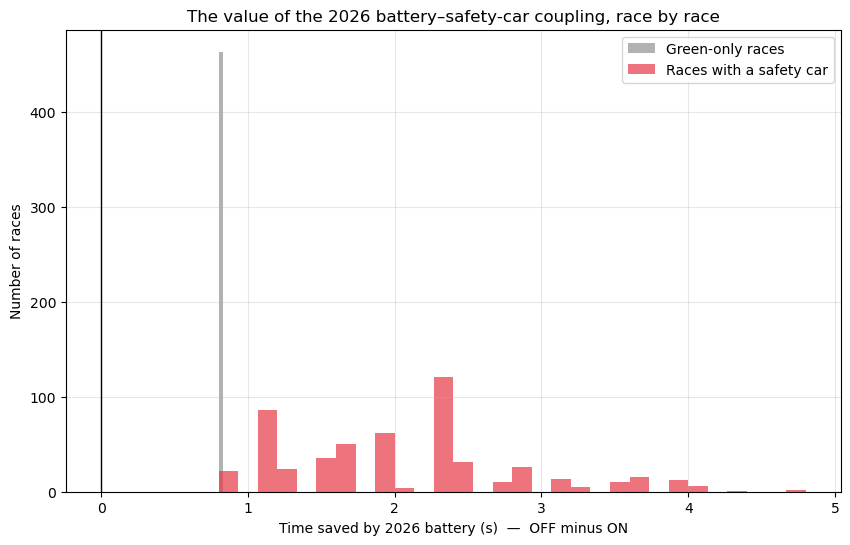

In [10]:
rng = np.random.default_rng(42)

def random_flags():
    seq, f = [], 0
    for _ in range(N_LAPS):
        seq.append(f)
        if f == 0:
            f = 1 if rng.random() < P_SC else 0
        else:
            f = 0 if rng.random() < Q_END else 1
    return seq

diffs, had_sc = [], []
for _ in range(1000):
    flags = random_flags()
    t_off, _, _ = simulate_b(P_off, E_off, flags, battery=False)
    t_on,  _, _ = simulate_b(P_on,  E_on,  flags, battery=True)
    diffs.append(t_off - t_on)          # positive = battery saved time
    had_sc.append(any(f > 0 for f in flags))

diffs = np.array(diffs); had_sc = np.array(had_sc)
print(f"Races simulated: 1000   (with SC: {had_sc.sum()}, green-only: {(~had_sc).sum()})")
print(f"Battery advantage, ALL races:        {diffs.mean():+.2f}s avg")
print(f"Battery advantage, SC races only:    {diffs[had_sc].mean():+.2f}s avg")
print(f"Battery advantage, green-only races: {diffs[~had_sc].mean():+.2f}s avg")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(diffs[~had_sc], bins=30, alpha=0.6, color='gray', label='Green-only races')
ax.hist(diffs[had_sc],  bins=30, alpha=0.7, color='#e63946', label='Races with a safety car')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Time saved by 2026 battery (s)  —  OFF minus ON')
ax.set_ylabel('Number of races')
ax.set_title('The value of the 2026 battery–safety-car coupling, race by race')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('battery_value_distribution.png', dpi=200, bbox_inches='tight')
plt.show()